In [ ]:
# import necessary libraries and install required packages

!pip install torch torchvision torchmetrics torch-fidelity -q

import io
import random
import itertools
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
import torchvision.utils as vutils
from torchmetrics.image.fid import FrechetInceptionDistance

In [ ]:
# Set random seeds for reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Define the hyperparameter search space

SEARCH_SPACE = {
    "noise_dim"     : [64, 100, 128],
    "g_lr"          : [0.0001, 0.0003, 0.0005],
    "d_lr"          : [0.0001, 0.0002],
    "beta1"         : [0.5],
    "batch_size"    : [64, 128],
    "base_channels" : [32, 64],
    "epochs"        : [30]
}

In [ ]:
''' 
This section defines a function to load the QuickDraw pizza dataset from a URL. 
The dataset is stored as a NumPy array in a .npy file. The function reads the data from the URL, 
loads it into a NumPy array, and optionally limits the number of samples returned.
'''

QUICKDRAW_PIZZA_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy"

def load_quickdraw_pizza(limit=None):
    with urllib.request.urlopen(QUICKDRAW_PIZZA_URL) as response:
        raw_bytes = response.read()

    data = np.load(io.BytesIO(raw_bytes), allow_pickle=False)

    if limit is not None:
        data = data[:limit]

    return data

In [ ]:
'''
This function takes a NumPy array of image data and a batch size, and returns a PyTorch DataLoader. 
The images are normalized to the range [-1, 1] and reshaped to have a single channel (grayscale). 
Dummy labels are created since the dataset is unlabeled, and a TensorDataset is constructed to pair the images with the labels. 
The DataLoader is set to shuffle the data for training.
'''

def get_dataloader(data_array, batch_size):
    images = torch.tensor(data_array, dtype=torch.float32)
    images = images.view(-1, 1, 28, 28) / 255.0
    images = (images - 0.5) / 0.5 # normalize to [-1, 1]

    # Create dummy labels for TensorDataset
    labels = torch.zeros(len(images), dtype=torch.long)

    dataset = TensorDataset(images, labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
'''
This function takes a NumPy array of image data and a number n, and displays the first
n images in a grid format. The images are converted to PyTorch tensors, normalized to the range [0, 1], 
and reshaped to have a single channel.
'''
def show_real_samples(data_array, n=64):
    images = torch.tensor(data_array[:n], dtype=torch.float32)
    images = images.view(-1, 1, 28, 28) / 255.0

    grid = vutils.make_grid(images, nrow=8, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    plt.title("Real QuickDraw Pizza Sketches")
    plt.axis("off")
    plt.show()

In [ ]:
# This function initializes the weights of the model.
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

# Define the Generator architectures for the DCGAN.
class Generator(nn.Module):
    def __init__(self, noise_dim=100, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            # input: [N, noise_dim, 1, 1]
            nn.ConvTranspose2d(noise_dim, base_channels * 4, kernel_size=4, stride=1, padding=0, bias=False),  # 4x4
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=3, stride=2, padding=1, bias=False), # 7x7
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1, bias=False),     # 14x14
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels, 1, kernel_size=4, stride=2, padding=1, bias=False),                     # 28x28
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


# Define the Discriminator architecture for the DCGAN.
class Discriminator(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            # input: [N, 1, 28, 28]
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1, bias=False),       # 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1, bias=False),  # 7x7
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, stride=2, padding=1, bias=False), # 4x4
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 4, 1, kernel_size=4, stride=1, padding=0, bias=False)     # 1x1
        )

    def forward(self, z):
        return self.net(z).view(-1)

In [ ]:
'''
This function calculates the Fréchet Inception Distance (FID) between real images from the dataloader and fake images generated by the generator.
The function first initializes the FID metric and sets the generator to evaluation mode. 
It then iterates through the dataloader to process real images, normalizing them to the range [0, 1], 
converting grayscale images to 3 channels if necessary, and resizing them to 299x299 for compatibility with the Inception model. 
The real images are fed into the FID metric.
'''

def calculate_fid(dataloader, generator, noise_dim, device=device, max_samples=2000):
    
    # Initialize the FID metric
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    generator.eval()

    # Get the real images from the dataloader and pass to the FID metric
    real_samples = 0
    for real_imgs, _ in dataloader:
        if real_samples >= max_samples:
            break

        real_imgs = real_imgs.to(device)
        batch_take = min(real_imgs.size(0), max_samples - real_samples)
        real_imgs = real_imgs[:batch_take]

        # [-1, 1] -> [0, 1]
        real_imgs = (real_imgs * 0.5 + 0.5).clamp(0, 1)

        # grayscale -> 3 channels
        if real_imgs.size(1) == 1:
            real_imgs = real_imgs.repeat(1, 3, 1, 1)

        # resize to 299x299 for Inception
        real_imgs = F.interpolate(real_imgs, size=(299, 299), mode="bilinear", align_corners=False)

        fid_metric.update(real_imgs, real=True)
        real_samples += batch_take

    # Generate fake images and pass to the FID metric
    fake_samples = 0
    while fake_samples < max_samples:
        batch_take = min(dataloader.batch_size, max_samples - fake_samples)
        noise = torch.randn(batch_take, noise_dim, 1, 1, device=device)

        with torch.no_grad():
            fake_imgs = generator(noise)

        # normalize to [0, 1]
        fake_imgs = (fake_imgs * 0.5 + 0.5).clamp(0, 1)

        # convert grayscale to 3 channels
        if fake_imgs.size(1) == 1:
            fake_imgs = fake_imgs.repeat(1, 3, 1, 1)

        # resize to 299x299 for Inception
        fake_imgs = F.interpolate(fake_imgs, size=(299, 299), mode="bilinear", align_corners=False)

        # update FID metric with fake images
        fid_metric.update(fake_imgs, real=False)
        fake_samples += batch_take

    fid_score = fid_metric.compute().item()
    generator.train()

    return fid_score

In [ ]:
'''
This function generates images using the trained generator and displays them side-by-side with real images from the dataloader.'''
def generate_images(dataloader, generator, noise_dim, n=16):
    generator.eval()

    # Generate real images from the dataloader
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:n].cpu()
    real_imgs = (real_imgs * 0.5 + 0.5).clamp(0, 1)

    # Create a grid from real images
    real_grid = vutils.make_grid(real_imgs, nrow=4, padding=2)

    # Generate the fake images
    with torch.no_grad():
        
        # Generate fake images 
        noise = torch.randn(n, noise_dim, 1, 1, device=device)
        fake_imgs = generator(noise).cpu()

    # normalize to [0, 1]
    fake_imgs = (fake_imgs * 0.5 + 0.5).clamp(0, 1)

    # Create a 4x4 grid from fake images
    fake_grid = vutils.make_grid(fake_imgs, nrow=4, padding=2)

    # Plot the real and fake images side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # plot real images
    axes[0].imshow(real_grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    axes[0].set_title("Real QuickDraw Pizza Sketches", fontsize=14)
    axes[0].axis("off")

    # Plot fake images
    axes[1].imshow(fake_grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    axes[1].set_title("Generated QuickDraw Pizza Sketches", fontsize=14)
    axes[1].axis("off")

    plt.suptitle("Real vs Generated Pizza Sketches", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    generator.train()

In [ ]:
'''
This function trains the GAN using the provided configuration and dataset
'''
def train_gan(config, data_array, fid_max_samples=1000, verbose=True):
    
    # Extract hyperparameters from the config dictionary
    noise_dim     = config["noise_dim"]
    g_lr          = config["g_lr"]
    d_lr          = config["d_lr"]
    beta1         = config["beta1"]
    batch_size    = config["batch_size"]
    epochs        = config["epochs"]
    base_channels = config["base_channels"]

    # Create dataloader from the data array
    dataloader = get_dataloader(data_array, batch_size)

    # Initialize the Generator and Discriminator
    gen  = Generator(noise_dim=noise_dim, base_channels=base_channels).to(device)
    disc = Discriminator(base_channels=base_channels).to(device)
    initialize_weights(gen)
    initialize_weights(disc)

    # Set up optimizers and loss function
    opt_g = optim.Adam(gen.parameters(),  lr=g_lr, betas=(beta1, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=d_lr, betas=(beta1, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    # Track losses and FID scores
    gen_losses, disc_losses, fid_scores = [], [], []
    best_fid   = float("inf")
    best_state = None

    # Training loop
    for epoch in range(epochs):
        total_gen_loss, total_disc_loss = [], []

        for real_imgs, _ in dataloader:
            real_imgs  = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # Discriminator training
            noise     = torch.randn(batch_size, noise_dim, 1, 1, device=device)
            fake_imgs = gen(noise).detach()

            opt_d.zero_grad()
            loss_real = criterion(disc(real_imgs),
                                  torch.ones(batch_size, device=device) * 0.9)
            loss_fake = criterion(disc(fake_imgs),
                                  torch.zeros(batch_size, device=device))
            disc_loss = (loss_real + loss_fake) / 2
            disc_loss.backward()
            opt_d.step()

            #  Generator training
            noise     = torch.randn(batch_size, noise_dim, 1, 1, device=device)
            fake_imgs = gen(noise)
            opt_g.zero_grad()
            gen_loss  = criterion(disc(fake_imgs), torch.ones(batch_size, device=device))
            gen_loss.backward()
            opt_g.step()

            # Record losses for this batch
            total_gen_loss.append(gen_loss.item())
            total_disc_loss.append(disc_loss.item())

        # Record average losses for this epoch
        gen_losses.append(np.mean(total_gen_loss))
        disc_losses.append(np.mean(total_disc_loss))

        # FID for every 10 epochs
        if (epoch + 1) % 10 == 0:
            fid = calculate_fid(dataloader, gen,
                                noise_dim=noise_dim,
                                max_samples=fid_max_samples)
            fid_scores.append(fid)

            # Save best generator weights
            if fid < best_fid:
                best_fid   = fid
                best_state = {i: j.detach().clone()
                              for i, j in gen.state_dict().items()}

            # Verbose flag used to avoid unnecessary loss print
            if verbose:
                print(f"Epoch [{epoch+1:3d}/{epochs}] | D Loss: {disc_losses[-1]:.4f} | G Loss: {gen_losses[-1]:.4f} | FID: {fid:.2f}")

    return {
        "generator"  : gen,
        "best_state" : best_state,
        "gen_losses" : gen_losses,
        "disc_losses": disc_losses,
        "fid_scores" : fid_scores,
        "best_fid"   : best_fid,
        "config"     : config
    }

In [ ]:
'''
This function samples a specified number of configurations from the hyperparameter search space.
It generates all possible combinations of hyperparameters using itertools.product, 
then randomly samples a specified number of configurations from this list.
'''

def sample_config(search_space, n_trials):
    
    # Generate all possible combinations of hyperparameters
  all_configs = list(itertools.product(
      search_space["noise_dim"],
      search_space["g_lr"],
      search_space["d_lr"],
      search_space["beta1"],
      search_space["batch_size"],
      search_space["base_channels"],
      search_space["epochs"]
  ))

    # Randomly sample n_trials configurations from the list of all possible combinations
  combo = random.sample(all_configs, k=min(n_trials, len(all_configs)))

    # Convert the sampled combinations into a list of config dictionaries
  configs = []
  
  # Iterate through the sampled combinations and create a config dictionary for each one
  for params in combo:
      config = {
          "noise_dim": params[0],
          "g_lr":params[1],
          "d_lr": params[2],
          "beta1": params[3],
          "batch_size": params[4],
          "base_channels": params[5],
          "epochs": params[6]
      }
      configs.append(config)

  return configs

In [ ]:
''' 
This function performs random search over the hyperparameter space. 
'''
def random_search(data_array, n_trials=3, fid_max_samples=1000):
    
    # List to store results of each trial
    results = []
    
    # Sample configurations from the search space
    sampled_config = sample_config(SEARCH_SPACE, n_trials)

    # Iterate through each sampled configuration, train the GAN, and store the results
    for trial, config in enumerate(sampled_config, start=1):
        print("\n" + "=" * 60)
        print(f"Random Search {trial}")
        print("Config:", config)

        output = train_gan(
            config,
            data_array,
            fid_max_samples=fid_max_samples,
            verbose=False
        )

        # Store the results for this trial
        results.append({
            "config": output["config"],
            "best_fid": output["best_fid"],
            "best_state": output["best_state"]
        })

        print(f"Random Search {trial} Best FID: {output['best_fid']:.2f}")

    best_run = min(results, key=lambda x: x["best_fid"])
    return best_run, results

In [ ]:
# Load the QuickDraw pizza dataset and print its shape
pizza_data = load_quickdraw_pizza(limit=20000)
print("Pizza data shape:", pizza_data.shape)

Pizza data shape: (20000, 784)


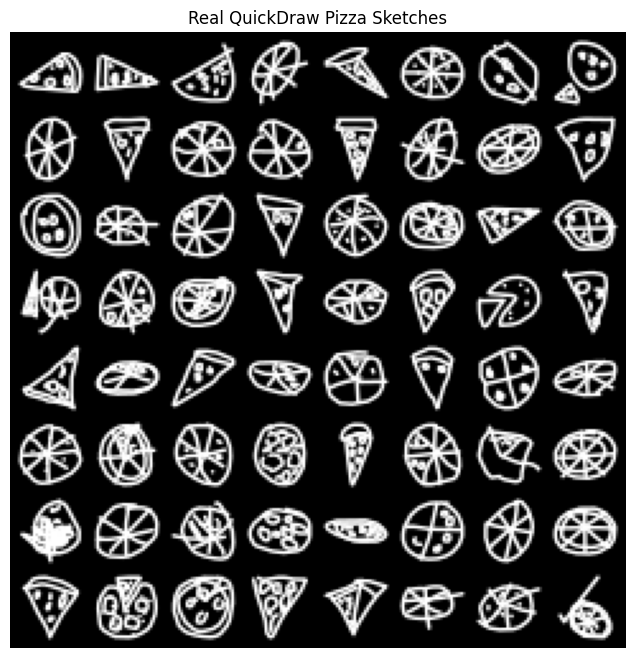

In [14]:
# Explore the dataset
show_real_samples(pizza_data, n=64)

In [ ]:
# Perform random search over the hyperparameter space and print the best configuration and its FID score
best_run, all_results = random_search(
    data_array=pizza_data,
    n_trials=4,
    fid_max_samples=1000
)

print("\nBest Random Search Config:")
print(best_run["config"])
print(f"Best Tuning FID: {best_run['best_fid']:.2f}")


Random Search 1
Config: {'noise_dim': 128, 'g_lr': 0.0005, 'd_lr': 0.0001, 'beta1': 0.5, 'batch_size': 64, 'base_channels': 32, 'epochs': 30}
Random Search 1 Best FID: 44.98

Random Search 2
Config: {'noise_dim': 64, 'g_lr': 0.0001, 'd_lr': 0.0002, 'beta1': 0.5, 'batch_size': 128, 'base_channels': 64, 'epochs': 30}
Random Search 2 Best FID: 55.41

Random Search 3
Config: {'noise_dim': 64, 'g_lr': 0.0001, 'd_lr': 0.0001, 'beta1': 0.5, 'batch_size': 64, 'base_channels': 64, 'epochs': 30}
Random Search 3 Best FID: 53.21

Random Search 4
Config: {'noise_dim': 128, 'g_lr': 0.0005, 'd_lr': 0.0002, 'beta1': 0.5, 'batch_size': 128, 'base_channels': 64, 'epochs': 30}
Random Search 4 Best FID: 37.98

Best Random Search Config:
{'noise_dim': 128, 'g_lr': 0.0005, 'd_lr': 0.0002, 'beta1': 0.5, 'batch_size': 128, 'base_channels': 64, 'epochs': 30}
Best Tuning FID: 37.98


In [ ]:
# copy the best configuration and update epochs for final training
final_config = best_run["config"].copy()
final_config["epochs"] = 50

print("Final training with best config")
print(final_config)

# Train the final model using the best configuration
final_result = train_gan(
    config=final_config,
    data_array=pizza_data,
    fid_max_samples=2000,
    verbose=True
)

# Extract the final generator
final_generator = final_result["generator"]

# Load the best generator weights from the random search results
final_generator.load_state_dict(final_result["best_state"])

Final training with best config
{'noise_dim': 128, 'g_lr': 0.0005, 'd_lr': 0.0002, 'beta1': 0.5, 'batch_size': 128, 'base_channels': 64, 'epochs': 50}
Epoch [ 10/50] | D Loss: 0.3297 | G Loss: 2.3234 | FID: 68.39
Epoch [ 20/50] | D Loss: 0.2483 | G Loss: 3.4482 | FID: 37.30
Epoch [ 30/50] | D Loss: 0.2504 | G Loss: 3.7481 | FID: 30.67
Epoch [ 40/50] | D Loss: 0.1834 | G Loss: 4.6846 | FID: 27.66
Epoch [ 50/50] | D Loss: 0.1873 | G Loss: 4.6510 | FID: 29.78


<All keys matched successfully>

In [17]:
# Final FID Output
print(f"Final Best FID Score: {final_result['best_fid']:.2f}")

Final Best FID Score: 27.66


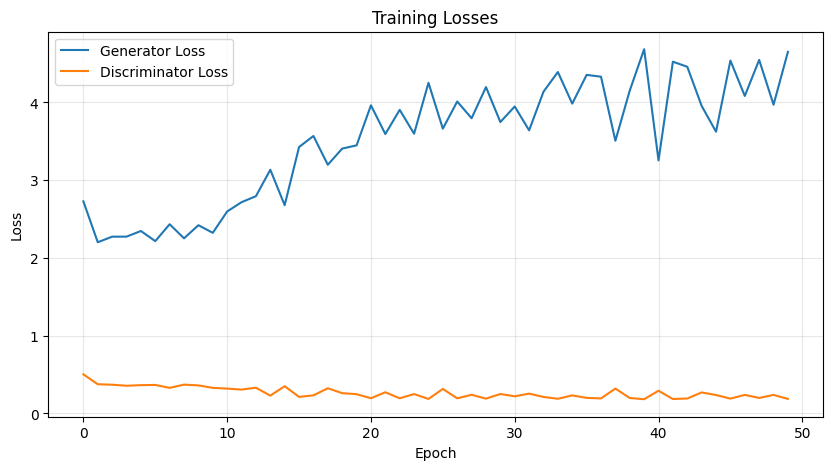

In [ ]:
# Plot the training losses over epochs
plt.figure(figsize=(10, 5))
plt.plot(final_result["gen_losses"], label="Generator Loss")
plt.plot(final_result["disc_losses"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

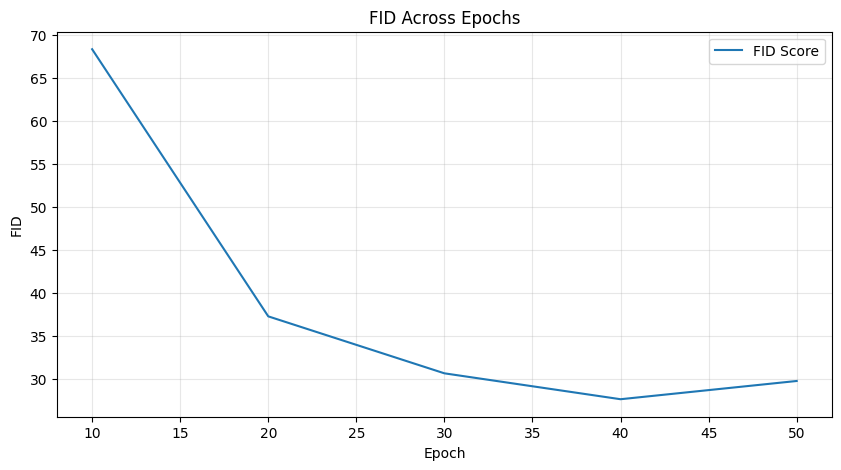

In [ ]:
# Plot the FID scores across epochs

plt.figure(figsize=(10, 5))

# Get epoch value
fid_epochs = [(i + 1) * 10 for i in range(len(final_result["fid_scores"]))]

plt.plot(fid_epochs, final_result["fid_scores"], label="FID Score")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID Across Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

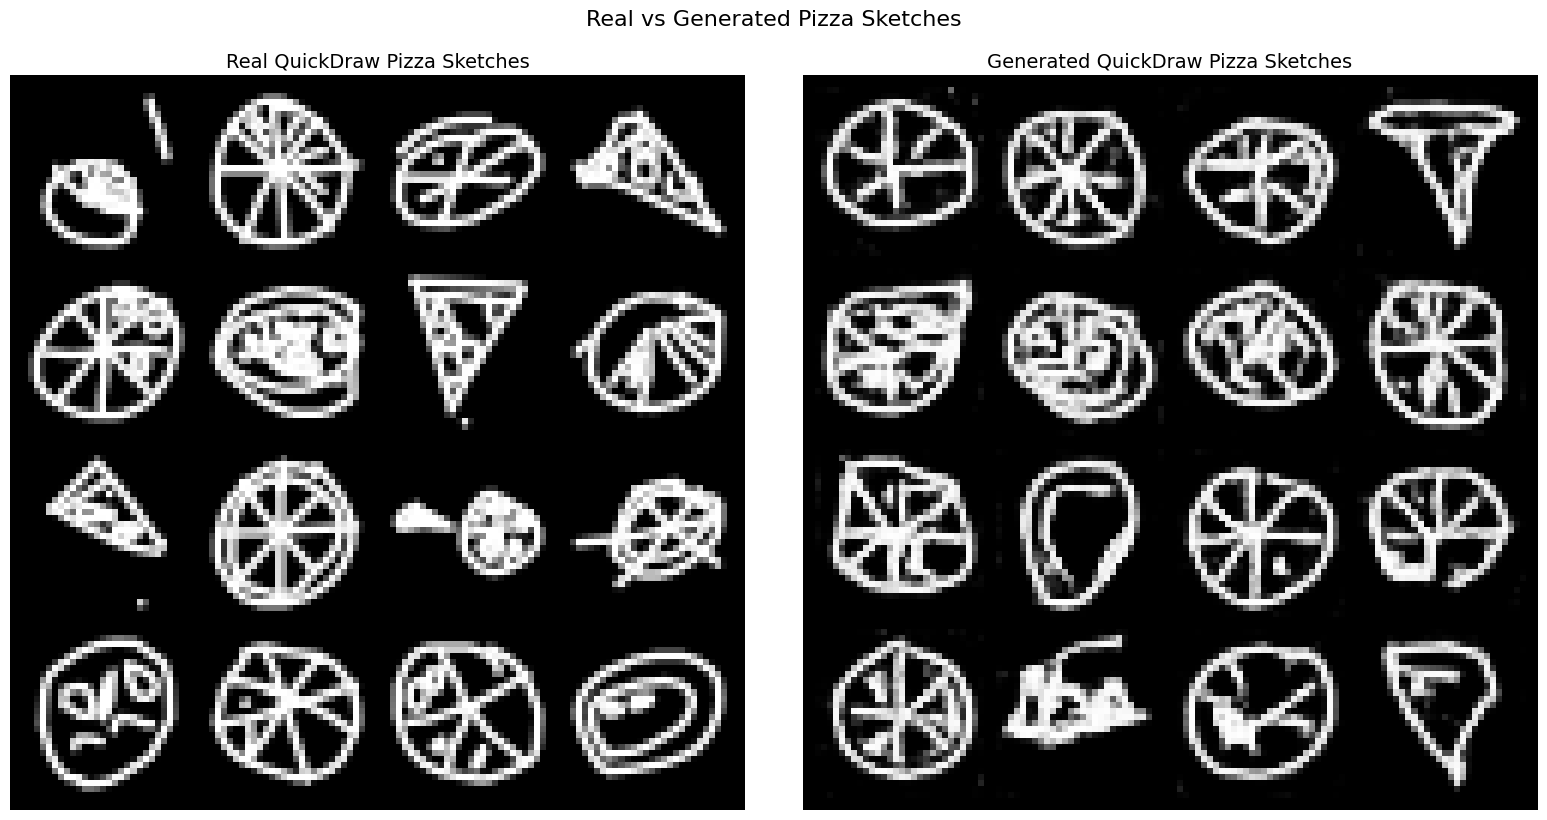

In [ ]:
# Generate real vs fake images
final_loader = get_dataloader(pizza_data, batch_size=final_config["batch_size"])
generate_images(dataloader=final_loader, generator=final_generator, noise_dim=final_config["noise_dim"], n=16)

In [21]:
# Recalculate the FID score of the final model
fid = calculate_fid(
    final_loader,
    final_generator,
    noise_dim=final_config["noise_dim"],
    device=device
)

print(f"Final FID of Final Model Config: {fid:.2f}")

Final FID of Final Model Config: 27.43
